In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

plt.style.use("ggplot")

In [8]:
df.columns

Index(['Review #', 'Brand', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')

In [9]:
df.shape

(2580, 6)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Review #  2580 non-null   float64
 1   Brand     2580 non-null   object 
 2   Style     2578 non-null   object 
 3   Country   2580 non-null   object 
 4   Stars     2580 non-null   object 
 5   Top Ten   41 non-null     object 
dtypes: float64(1), object(5)
memory usage: 121.1+ KB


In [11]:
df.describe(include='all')

,Review #,Brand,Style,Country,Stars,Top Ten
count,2.580000e+03,2580,2578,2580,2580,41
unique,NaN,355,7,38,51,38
top,NaN,Nissin,Pack,Japan,4,\n
freq,NaN,381,1531,352,384,4
mean,-8.812933e-17,NaN,NaN,NaN,NaN,NaN
std,1.000194e+00,NaN,NaN,NaN,NaN,NaN
min,-1.731380e+00,NaN,NaN,NaN,NaN,NaN
25%,-8.656898e-01,NaN,NaN,NaN,NaN,NaN
50%,9.996344e-17,NaN,NaN,NaN,NaN,NaN
75%,8.656898e-01,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

,0
Review #,0
Brand,0
Style,2
Country,0
Stars,0
Top Ten,2539


In [13]:
df['Top Ten'] = df['Top Ten'].fillna("Not Ranked")

In [14]:
df['Stars'] = pd.to_numeric(df['Stars'], errors='coerce')

In [15]:
df['Stars'].fillna(df['Stars'].median(), inplace=True)

/tmp/ipykernel_3099/3102070578.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Stars'].fillna(df['Stars'].median(), inplace=True)


In [16]:
df.isnull().sum()

,0
Review #,0
Brand,0
Style,2
Country,0
Stars,0
Top Ten,0


In [17]:
brand_count = df['Brand'].value_counts()

df['Brand_Popularity'] = df['Brand'].map(brand_count)

df[['Brand','Brand_Popularity']].head()

,Brand,Brand_Popularity
0,New Touch,9
1,Just Way,2
2,Nissin,381
3,Wei Lih,15
4,Ching's Secret,4


In [18]:
country_count = df['Country'].value_counts()

df['Country_Popularity'] = df['Country'].map(country_count)

df[['Country','Country_Popularity']].head()

,Country,Country_Popularity
0,Japan,352
1,Taiwan,224
2,USA,323
3,Taiwan,224
4,India,31


In [19]:
avg_brand = df.groupby("Brand")["Stars"].mean()

df["Premium_Brand"] = df["Brand"].map(avg_brand)

df["Premium_Brand"] = np.where(df["Premium_Brand"]>=4,1,0)

df[['Brand','Premium_Brand']].head()

,Brand,Premium_Brand
0,New Touch,1
1,Just Way,0
2,Nissin,0
3,Wei Lih,0
4,Ching's Secret,0


In [20]:
style_map = {
    "Pack":1,
    "Cup":2,
    "Bowl":3,
    "Tray":4,
    "Box":5
}

df["Style_Code"] = df["Style"].map(style_map)

df[['Style','Style_Code']].head()

,Style,Style_Code
0,Cup,2.0
1,Pack,1.0
2,Cup,2.0
3,Pack,1.0
4,Pack,1.0


In [21]:
df['Rating_Category'] = pd.cut(
    df['Stars'],
    bins=[0,2,3.5,5],
    labels=['Low','Medium','High']
)

df[['Stars','Rating_Category']].head()

,Stars,Rating_Category
0,3.75,High
1,1.00,Low
2,2.25,Medium
3,2.75,Medium
4,3.75,High


In [22]:
df['Top_Product'] = np.where(df['Top Ten']=="Not Ranked",0,1)

df[['Top Ten','Top_Product']].head()

,Top Ten,Top_Product
0,Not Ranked,0
1,Not Ranked,0
2,Not Ranked,0
3,Not Ranked,0
4,Not Ranked,0


In [23]:
encoder = LabelEncoder()

df["Brand"] = encoder.fit_transform(df["Brand"])

df["Country"] = encoder.fit_transform(df["Country"])

df["Style"] = encoder.fit_transform(df["Style"])

In [24]:
df = pd.get_dummies(
    df,
    columns=['Rating_Category'],
    drop_first=True
)

df.head()

,Review #,Brand,Style,Country,Stars,Top Ten,Brand_Popularity,Country_Popularity,Premium_Brand,Style_Code,Top_Product,Rating_Category_Medium,Rating_Category_High
0,1.731380,190,4,18,3.75,Not Ranked,9,352,1,2.0,0,False,True
1,1.730037,119,5,32,1.00,Not Ranked,2,224,0,1.0,0,False,False
2,1.728694,192,4,35,2.25,Not Ranked,381,323,0,2.0,0,True,False
3,1.727352,336,5,32,2.75,Not Ranked,15,224,0,1.0,0,True,False
4,1.726009,38,5,16,3.75,Not Ranked,4,31,0,1.0,0,False,True


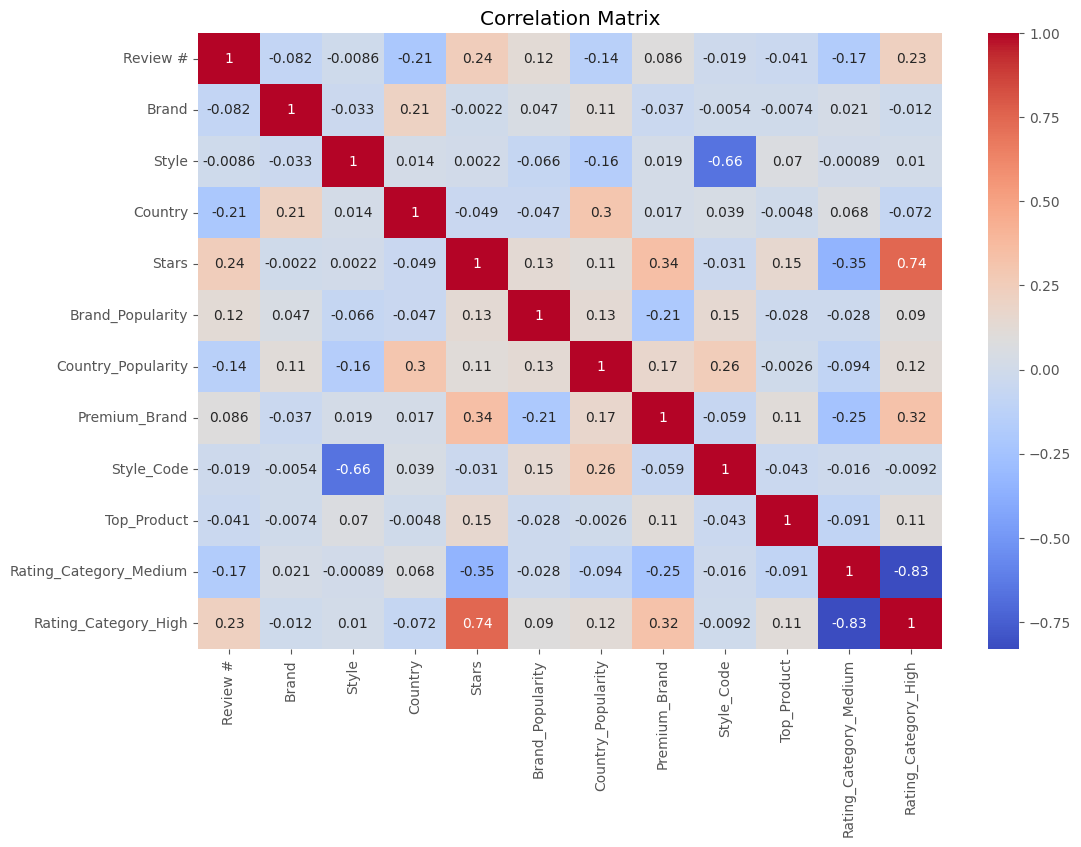

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Fill NaN values in 'Style_Code' which might have been introduced during mapping
df['Style_Code'].fillna(df['Style_Code'].median(), inplace=True)

X = df.drop(columns=['Stars','Top Ten'])

X = X.select_dtypes(include=np.number)

# Diagnostic: Check for NaNs in X before splitting
print("\nNaNs in X before splitting:")
print(X.isnull().sum())
print("\nInfo of X before splitting:")
X.info()

y = df['Stars']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2 Score:",r2_score(y_test,pred))


NaNs in X before splitting:
Review #              0
Brand                 0
Style                 0
Country               0
Brand_Popularity      0
Country_Popularity    0
Premium_Brand         0
Style_Code            0
Top_Product           0
dtype: int64

Info of X before splitting:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Review #            2580 non-null   float64
 1   Brand               2580 non-null   int64  
 2   Style               2580 non-null   int64  
 3   Country             2580 non-null   int64  
 4   Brand_Popularity    2580 non-null   int64  
 5   Country_Popularity  2580 non-null   int64  
 6   Premium_Brand       2580 non-null   int64  
 7   Style_Code          2580 non-null   float64
 8   Top_Product         2580 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 181.5 KB
R2 Score: 0.2470

/tmp/ipykernel_3099/3087772896.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Style_Code'].fillna(df['Style_Code'].median(), inplace=True)


In [28]:
from sklearn.cluster import KMeans

features = X.select_dtypes(include=np.number)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(features)

df[['Cluster']].head()

,Cluster
0,0
1,2
2,1
3,0
4,2


In [30]:
importance = pd.Series(
    model.coef_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

Top_Product           1.057555
Premium_Brand         0.772601
Review #              0.187368
Brand_Popularity      0.001407
Country_Popularity    0.000768
Brand                 0.000204
Country              -0.003479
Style                -0.014367
Style_Code           -0.077596
dtype: float64


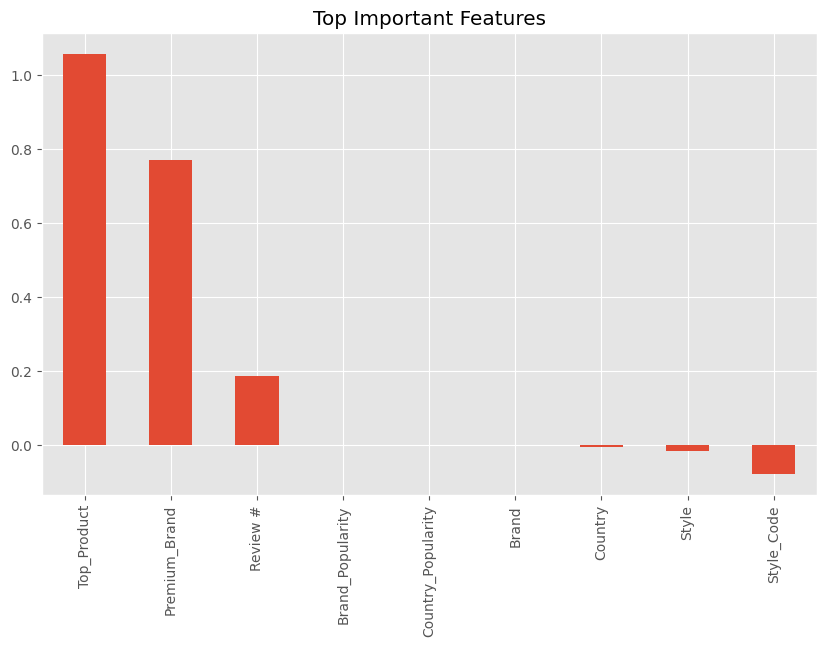

In [31]:
plt.figure(figsize=(10,6))

importance.head(10).plot(kind='bar')

plt.title("Top Important Features")

plt.show()

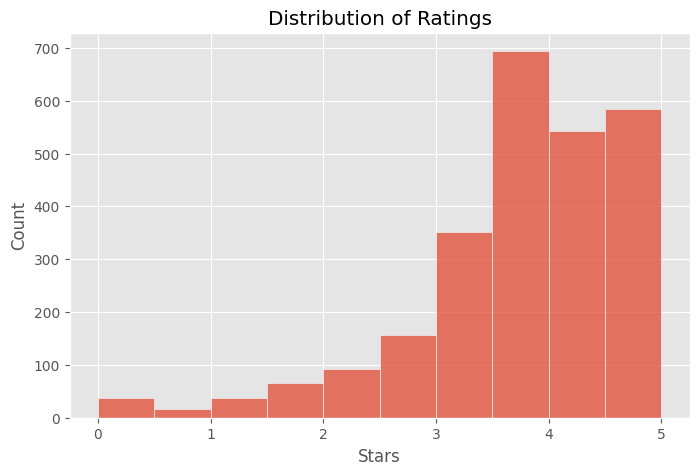

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df['Stars'],bins=10)

plt.title("Distribution of Ratings")

plt.show()

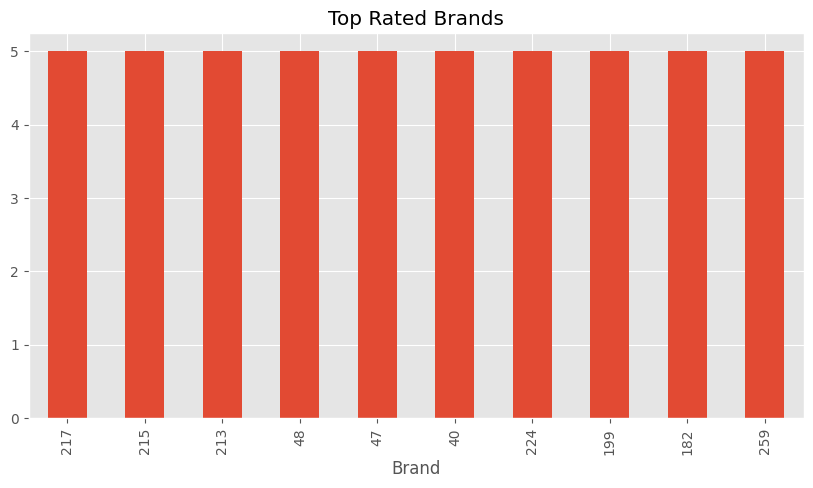

In [33]:
brand_rating = df.groupby('Brand')['Stars'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

brand_rating.plot(kind='bar')

plt.title("Top Rated Brands")

plt.show()

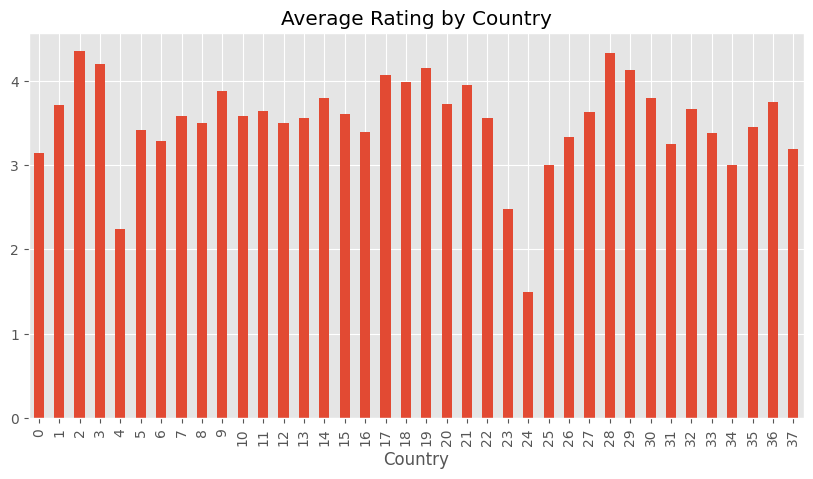

In [34]:
country_rating = df.groupby('Country')['Stars'].mean()

plt.figure(figsize=(10,5))

country_rating.plot(kind='bar')

plt.title("Average Rating by Country")

plt.show()

In [35]:
df.to_csv(
    "food_feature_engineered.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully
